In [ ]:
import pandas as pd

df = pd.read_csv("kepler.csv", comment="#")

print(df['koi_disposition'].value_counts())
print()
df.head()





koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64
0         93.59
1          9.11
2         39.30
3        891.96
4        926.16
         ...   
9559    4500.53
9560    1585.81
9561    5713.41
9562      22.68
9563     607.42
Name: koi_insol, Length: 9564, dtype: float64


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.969,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.000,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200


In [8]:
goldilock_query = (
    "koi_disposition == 'CONFIRMED' and "
    "0.5 <= koi_prad <= 2.0 and "
    "200 <= koi_teq <= 320"
)

earth_like = df.query(goldilock_query)

view = earth_like[['kepler_name', 'koi_period', 'koi_prad', "koi_teq"]]
print(f"From {len(df)} Kepler data earth like planet count: {len(earth_like)}")

print(view.to_markdown())

From 9564 Kepler data earth like planet count: 31
|      | kepler_name   |   koi_period |   koi_prad |   koi_teq |
|-----:|:--------------|-------------:|-----------:|----------:|
|   86 | Kepler-235 e  |      46.1842 |       1.83 |       273 |
|  170 | Kepler-705 b  |      56.0561 |       1.94 |       233 |
|  533 | Kepler-267 d  |      28.4646 |       1.87 |       301 |
|  561 | Kepler-737 b  |      28.5991 |       1.83 |       298 |
|  978 | Kepler-296 d  |      19.8503 |       1.52 |       297 |
|  987 | Kepler-283 c  |      92.7496 |       1.87 |       240 |
| 1290 | Kepler-69 c   |     242.467  |       1.73 |       286 |
| 1300 | Kepler-309 c  |     105.358  |       1.87 |       204 |
| 1808 | Kepler-1816 b |      91.5009 |       1.82 |       310 |
| 2059 | Kepler-395 c  |      34.9898 |       1.14 |       292 |
| 2285 | Kepler-1652 b |      38.0971 |       1.58 |       242 |
| 2660 | Kepler-1410 b |      60.8661 |       1.39 |       244 |
| 3111 | Kepler-577 b  |      25.6958 | 

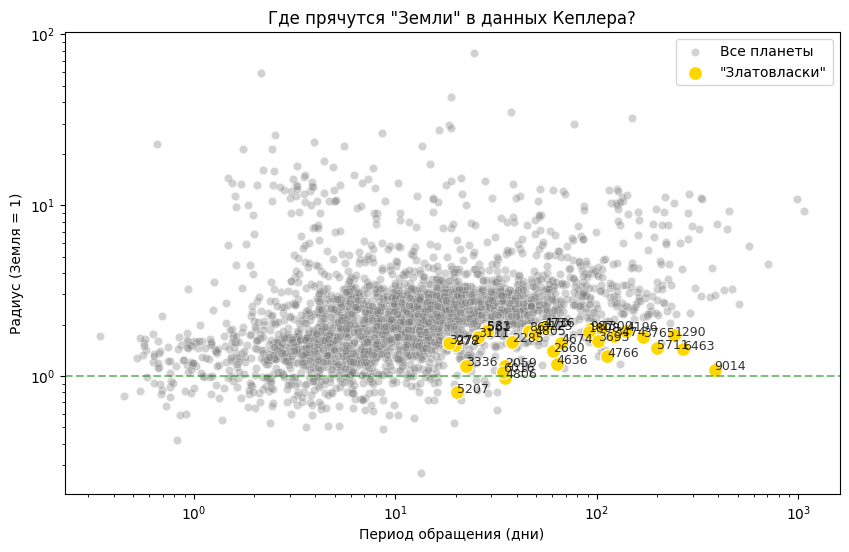

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Earth like planets painted grayРисуем все подтвержденные планеты серым цветом
sns.scatterplot(data=df[df['koi_disposition']=='CONFIRMED'], 
                x='koi_period', y='koi_prad', color='grey', alpha=0.35, label='Все планеты')

# "Goldilock zone"painted gold
sns.scatterplot(data=earth_like, 
                x='koi_period', y='koi_prad', color='gold', s=100, label='"Златовласки"')

plt.xscale('log') # В виде логарифма, т.к. год бывает от 1 до 1000 дней
plt.yscale('log') # В виде логарифма, т.к. радиус бывает от 0.1 до 100
plt.axhline(1, color='green', linestyle='--', alpha=0.5) # Линия радиуса Земли
plt.title('Где прячутся "Земли" в данных Кеплера?')
plt.xlabel('Период обращения (дни)')
plt.ylabel('Радиус (Земля = 1)')
plt.legend()

for i, row in earth_like.iterrows():
    plt.text(
        x=row['koi_period'], 
        y=row['koi_prad'], 
        s=str(i),          # Текст подписи - это индекс строки
        fontsize=9,        # Размер шрифта
        color='black',     # Цвет подписи
        alpha=0.8          # Прозрачность, чтобы не перекрывать точку
    )
    
plt.show()

# Potential Earth-like
# Kepler-62 f
# Kepler-452 b
# Kepler-1126 c
# Kepler-442 b
# Kepler-1544 b